<a href="https://colab.research.google.com/github/mridulasrinivasula-svg/OPTN-Model/blob/main/St_sensitivity_OAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ETA SENSITIVITY
eta = 1.5e-07 | S(2025) = 81.26 %
eta = 2.25e-07 | S(2025) = 88.06 %
eta = 3e-07 | S(2025) = 94.86 %
eta = 3.75e-07 | S(2025) = 101.67 %
eta = 4.5e-07 | S(2025) = 108.47 %


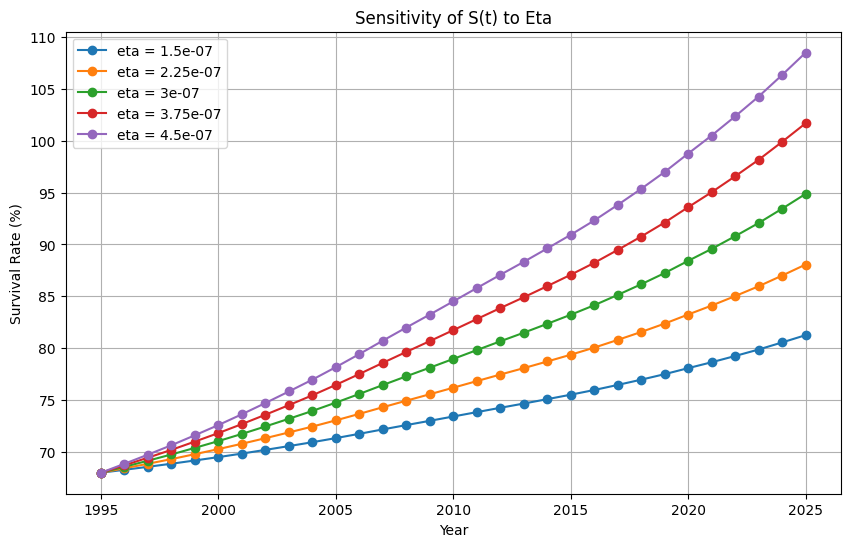


DELTA SENSITIVITY
delta = 1e-07 | S(2025) = 95.04 %
delta = 1.5e-07 | S(2025) = 94.95 %
delta = 2e-07 | S(2025) = 94.86 %
delta = 2.5e-07 | S(2025) = 94.78 %
delta = 3e-07 | S(2025) = 94.69 %


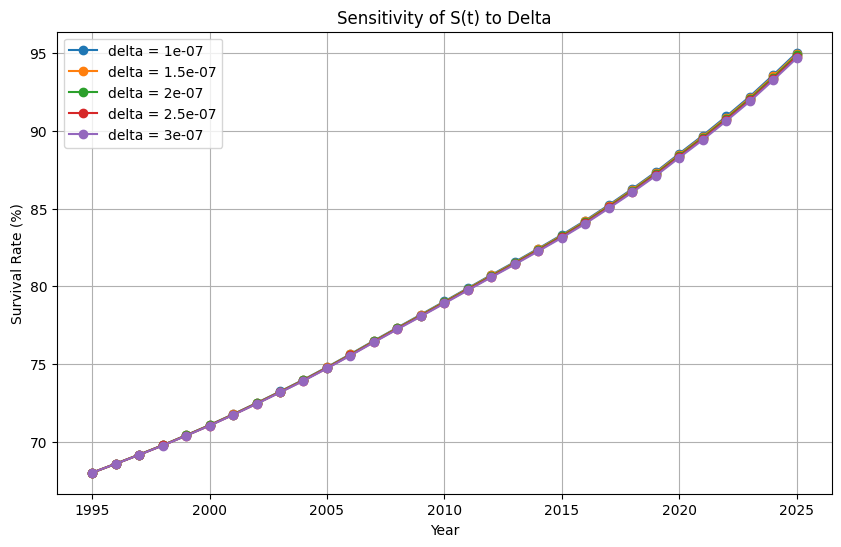


BASELINE MODEL
Eta = 3e-07
Delta = 2e-07
S(1995) = 68.0 %
S(2025) = 94.86 %
Minimum S = 68.0 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# DATA
# ============================================

years = np.arange(1995, 2026)

T = np.array([
    19396, 19765, 20316, 21526, 22030, 23274, 24243, 24916,
    25475, 27042, 28119, 28941, 28366, 27967, 28463, 28668,
    28553, 28059, 28956, 29540, 30974, 33610, 34770, 36530,
    39719, 39036, 41356, 42889, 46634, 48150, 49065
], dtype=float)

M = np.array([
    420,
    412.5479626,
    407.9312735,
    405.8567493,
    405.2737588,
    408.109529,
    412.5487649,
    418.9759869,
    426.8255602,
    434.0933164,
    440.1347854,
    447.235016,
    455.3027897,
    468.0361023,
    485.4782259,
    505.8362702,
    530.7212438,
    561.3317308,
    596.7810515,
    635.1406185,
    677.6969049,
    721.4419713,
    760.8739524,
    798.3725344,
    832.6220983,
    862.6383938,
    896.9299512,
    925.8841818,
    953.6295418,
    976.1524786,
    998.432
], dtype=float)


# ============================================
# INITIAL CONDITION
# ============================================

S0 = 0.68

# Baseline parameters
eta_baseline = 0.0000003
delta_baseline = 0.0000002


# ============================================
# MODEL
# ============================================

def simulate_S(eta, delta):

    S = np.zeros(len(years))

    S[0] = S0

    for t in range(len(years) - 1):

        S[t + 1] = (
            S[t]
            + eta * T[t]
            - delta * M[t]
        )

    return S


# ============================================
# ETA SENSITIVITY
# ============================================

eta_values = [
    0.00000015,
    0.000000225,
    0.0000003,
    0.000000375,
    0.00000045
]

print("============================================")
print("ETA SENSITIVITY")
print("============================================")

plt.figure(figsize=(10, 6))

for eta in eta_values:

    S = simulate_S(
        eta,
        delta_baseline
    )

    print(
        "eta =", eta,
        "| S(2025) =", round(S[-1] * 100, 2),
        "%"
    )

    plt.plot(
        years,
        S * 100,
        marker="o",
        label=f"eta = {eta}"
    )

plt.xlabel("Year")
plt.ylabel("Survival Rate (%)")
plt.title("Sensitivity of S(t) to Eta")
plt.legend()
plt.grid(True)

plt.show()


# ============================================
# DELTA SENSITIVITY
# ============================================

delta_values = [
    0.0000001,
    0.00000015,
    0.0000002,
    0.00000025,
    0.0000003
]

print("\n============================================")
print("DELTA SENSITIVITY")
print("============================================")

plt.figure(figsize=(10, 6))

for delta in delta_values:

    S = simulate_S(
        eta_baseline,
        delta
    )

    print(
        "delta =", delta,
        "| S(2025) =", round(S[-1] * 100, 2),
        "%"
    )

    plt.plot(
        years,
        S * 100,
        marker="o",
        label=f"delta = {delta}"
    )

plt.xlabel("Year")
plt.ylabel("Survival Rate (%)")
plt.title("Sensitivity of S(t) to Delta")
plt.legend()
plt.grid(True)

plt.show()


# ============================================
# BASELINE MODEL
# ============================================

S_baseline = simulate_S(
    eta_baseline,
    delta_baseline
)

print("\n============================================")
print("BASELINE MODEL")
print("============================================")

print("Eta =", eta_baseline)
print("Delta =", delta_baseline)
print("S(1995) =", S_baseline[0] * 100, "%")
print("S(2025) =", round(S_baseline[-1] * 100, 2), "%")
print("Minimum S =", round(np.min(S_baseline) * 100, 2), "%")